In [1]:
import os
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

### Configuration & Spark session

In [2]:
PROJECT_ROOT = Path(
    r"D:\Fourth Semester\Big Data\Project\Timetable-Based Bus Route Performance Analytics"
).resolve()
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DIR", PROJECT_ROOT / "output"))
EVAL_DIR = OUTPUT_DIR / "eval_predictions"

N_CORES = int(os.environ.get("SPARK_CORES", "8"))

spark = (
    SparkSession.builder
    .appName("BusRoute_06_ModelEvaluation")
    .master(f"local[{N_CORES}]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 3.5.8


In [3]:
comparison_df = pd.read_csv(OUTPUT_DIR / "model_comparison.csv")

with open(OUTPUT_DIR / "cv_results.json") as f:
    cv_results = json.load(f)

with open(OUTPUT_DIR / "feature_importance.json") as f:
    feature_importance = json.load(f)

model_names = comparison_df["Model"].tolist()
label_names = feature_importance["label_names"]
assembler_inputs = feature_importance["assembler_inputs"]

predictions = {}
for name in model_names:
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    path = EVAL_DIR / f"{safe_name}.parquet"
    predictions[name] = spark.read.parquet(str(path)).cache()

print("Models loaded:", model_names)
print("Classes:", label_names)
print()
print(comparison_df.to_string(index=False))

Models loaded: ['Random Forest', 'Decision Tree', 'Logistic Regression (baseline)']
Classes: ['High', 'Medium', 'Low']

                         Model  Training Time (s)  accuracy  weightedPrecision  weightedRecall     f1
                 Random Forest            17298.8    0.6998             0.7007          0.6998 0.6991
                 Decision Tree             2550.4    0.6056             0.6002          0.6056 0.5932
Logistic Regression (baseline)             1131.6    0.5665             0.5773          0.5665 0.5707


## Core metrics: Accuracy, Precision, Recall, F1

In [4]:
metrics_table = comparison_df[["Model", "accuracy", "weightedPrecision", "weightedRecall", "f1", "Training Time (s)"]]
metrics_table = metrics_table.rename(columns={
    "weightedPrecision": "Precision", "weightedRecall": "Recall", "f1": "F1", "accuracy": "Accuracy"
})
print(metrics_table.to_string(index=False))

                         Model  Accuracy  Precision  Recall     F1  Training Time (s)
                 Random Forest    0.6998     0.7007  0.6998 0.6991            17298.8
                 Decision Tree    0.6056     0.6002  0.6056 0.5932             2550.4
Logistic Regression (baseline)    0.5665     0.5773  0.5665 0.5707             1131.6


In [5]:
PALETTES = {
    "Accuracy":  ["#4E79A7", "#59A14F", "#F28E2B"],  
    "Precision": ["#E15759", "#76B7B2", "#EDC948"],  
    "Recall":    ["#AF7AA1", "#FF9DA7", "#9C755F"],  
    "F1":        ["#2F5597", "#70AD47", "#ED7D31"],  
}

In [7]:
MODEL_COLORS = {
    "Logistic Regression (baseline)": "#8C8C8C",  
    "Decision Tree": "#4C72B0",                   
    "Random Forest": "#55A868",                    
}

def model_color(name):
    return MODEL_COLORS.get(name, "#2C6E9B")

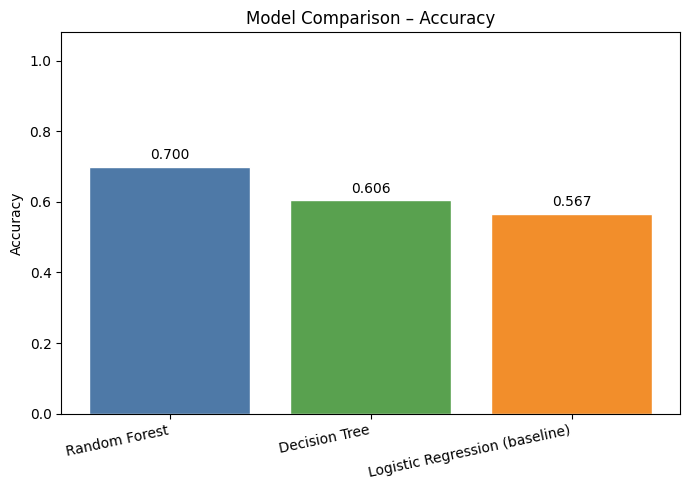

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    metrics_table["Model"],
    metrics_table["Accuracy"],
    color=PALETTES["Accuracy"],
    edgecolor="white",
    linewidth=1
)

ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison – Accuracy")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

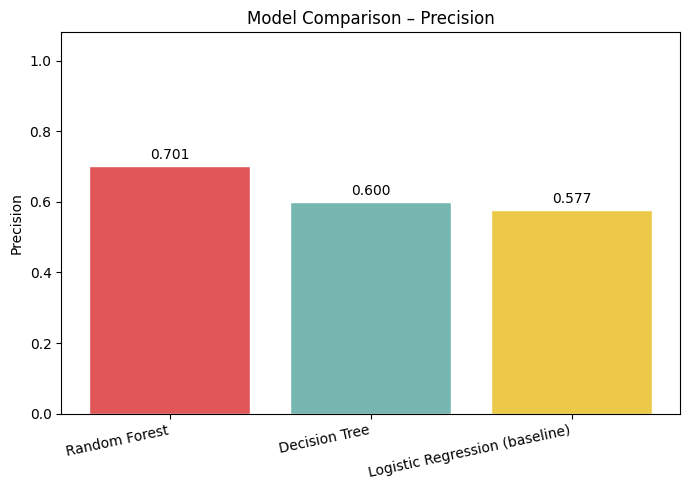

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    metrics_table["Model"],
    metrics_table["Precision"],
    color=PALETTES["Precision"],
    edgecolor="white",
    linewidth=1
)

ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Precision")
ax.set_title("Model Comparison – Precision")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

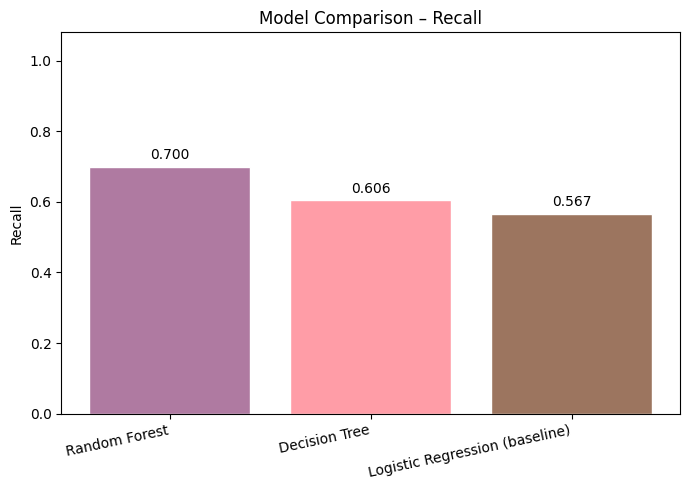

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    metrics_table["Model"],
    metrics_table["Recall"],
    color=PALETTES["Recall"],
    edgecolor="white",
    linewidth=1
)

ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Recall")
ax.set_title("Model Comparison – Recall")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

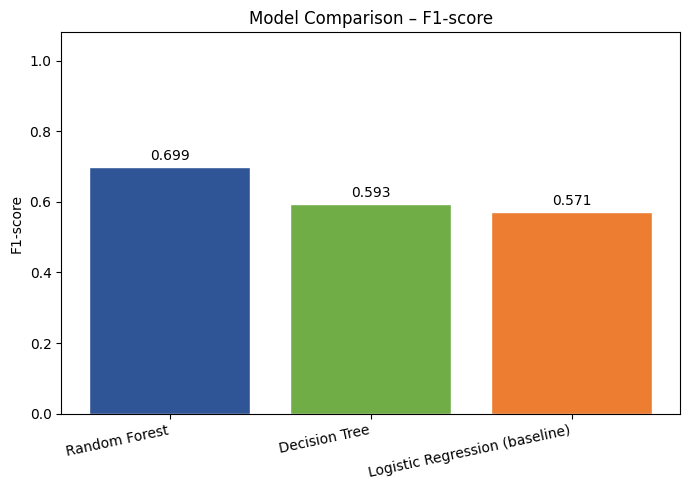

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    metrics_table["Model"],
    metrics_table["F1"],
    color=PALETTES["F1"],
    edgecolor="white",
    linewidth=1
)

ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylim(0, 1.08)
ax.set_ylabel("F1-score")
ax.set_title("Model Comparison – F1-score")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

## Confusion matrices

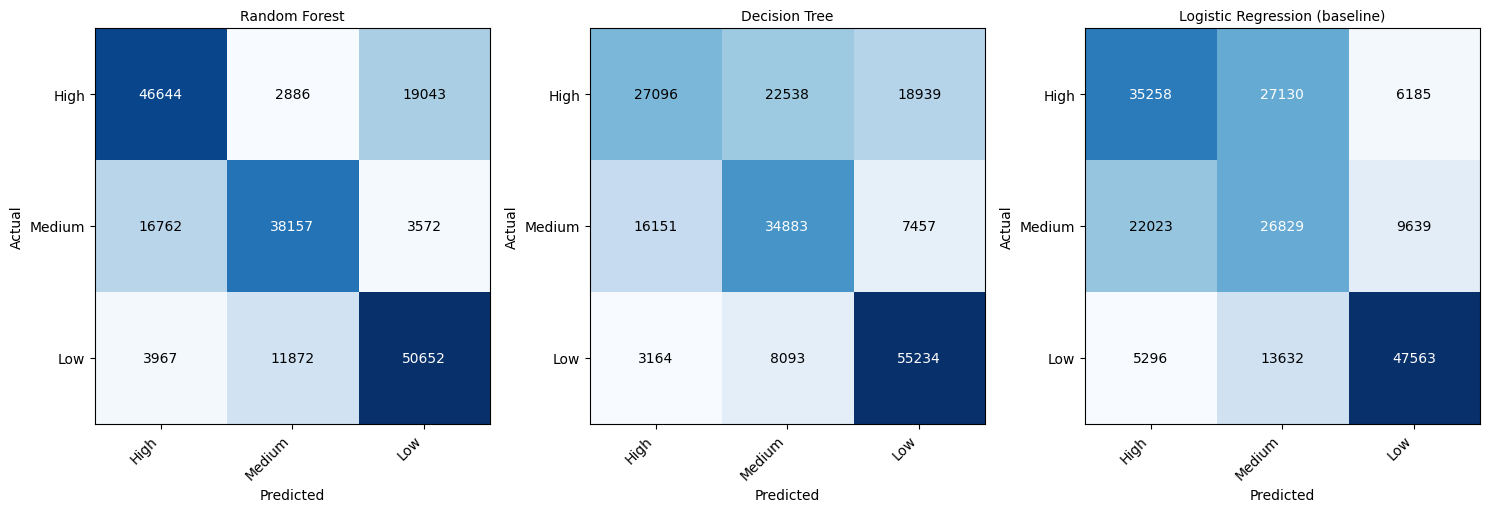

In [12]:
n_classes = len(label_names)

def confusion_matrix_from_spark(preds_df):
    counts = (
        preds_df.groupBy("label", "prediction").count()
        .toPandas()
        .astype({"label": int, "prediction": int})
    )
    matrix = np.zeros((n_classes, n_classes), dtype=int)
    for _, row in counts.iterrows():
        matrix[int(row["label"]), int(row["prediction"])] = row["count"]
    return matrix

confusion_matrices = {name: confusion_matrix_from_spark(df) for name, df in predictions.items()}

fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 5))
for ax, name in zip(axes, model_names):
    cm = confusion_matrices[name]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(range(n_classes)); ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticks(range(n_classes)); ax.set_yticklabels(label_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

## ROC curves 

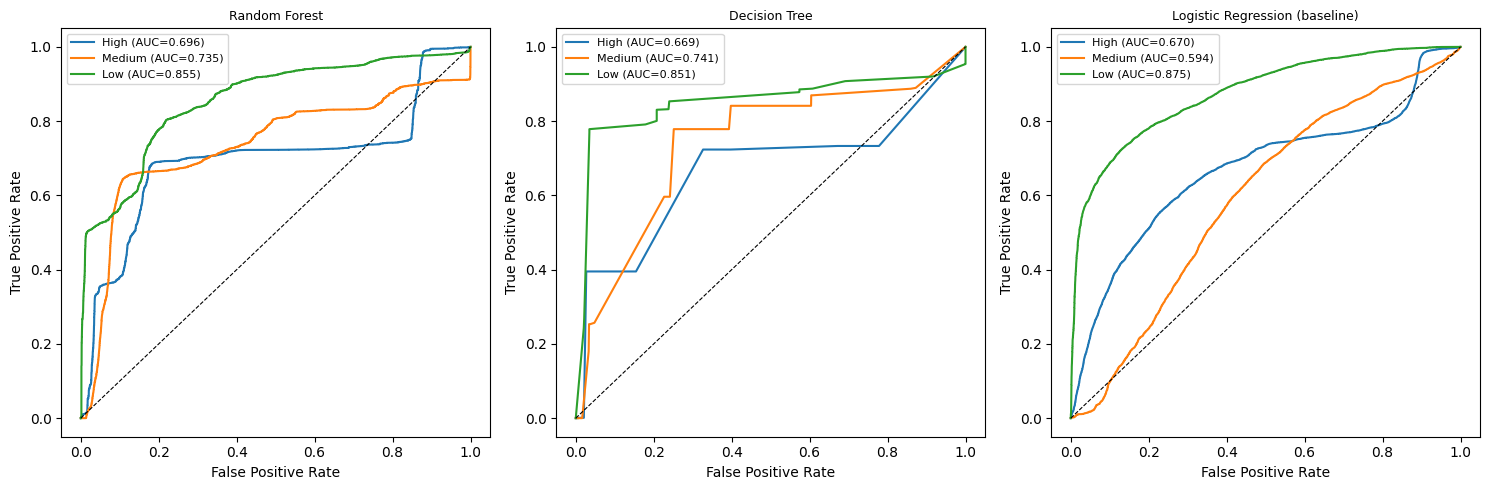

In [13]:
from sklearn.metrics import roc_curve, auc

def get_roc_data(preds_df, has_probability):
    pdf = preds_df.select("label", "prediction", *(["probability_array"] if has_probability else [])).toPandas()
    roc_data = {}
    for class_idx, class_name in enumerate(label_names):
        y_true = (pdf["label"] == class_idx).astype(int)
        if has_probability:
            y_score = pdf["probability_array"].apply(lambda arr: arr[class_idx])
        else:
            y_score = (pdf["prediction"] == class_idx).astype(int)
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_data[class_name] = (fpr, tpr, auc(fpr, tpr))
    return roc_data

fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 5))
for ax, name in zip(axes, model_names):
    has_prob = "probability_array" in predictions[name].columns
    roc_data = get_roc_data(predictions[name], has_prob)
    for class_name, (fpr, tpr, roc_auc) in roc_data.items():
        ax.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    title_suffix = "" if has_prob else "\n(approximate -- no calibrated probability)"
    ax.set_title(f"{name}{title_suffix}", fontsize=9)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Feature importance

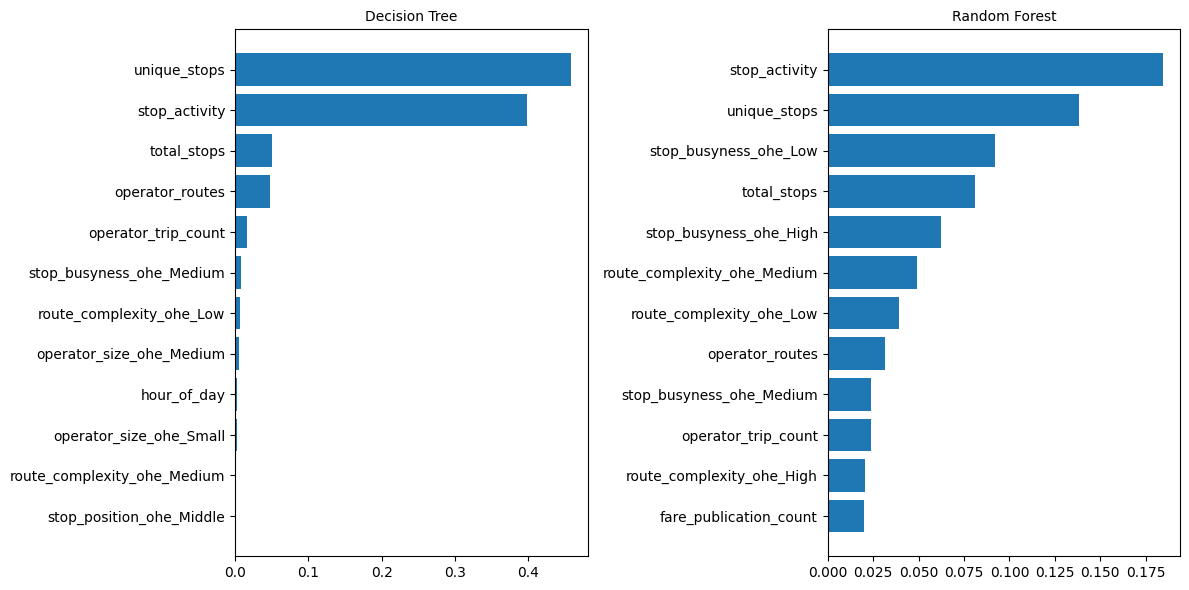

In [14]:
importance_sources = dict(feature_importance["tree_importances"])

fig, axes = plt.subplots(1, len(importance_sources), figsize=(6 * len(importance_sources), 6))
for ax, (name, importances) in zip(axes, importance_sources.items()):
    imp_df = pd.DataFrame({"feature": assembler_inputs, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=True).tail(12)
    ax.barh(imp_df["feature"], imp_df["importance"])
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

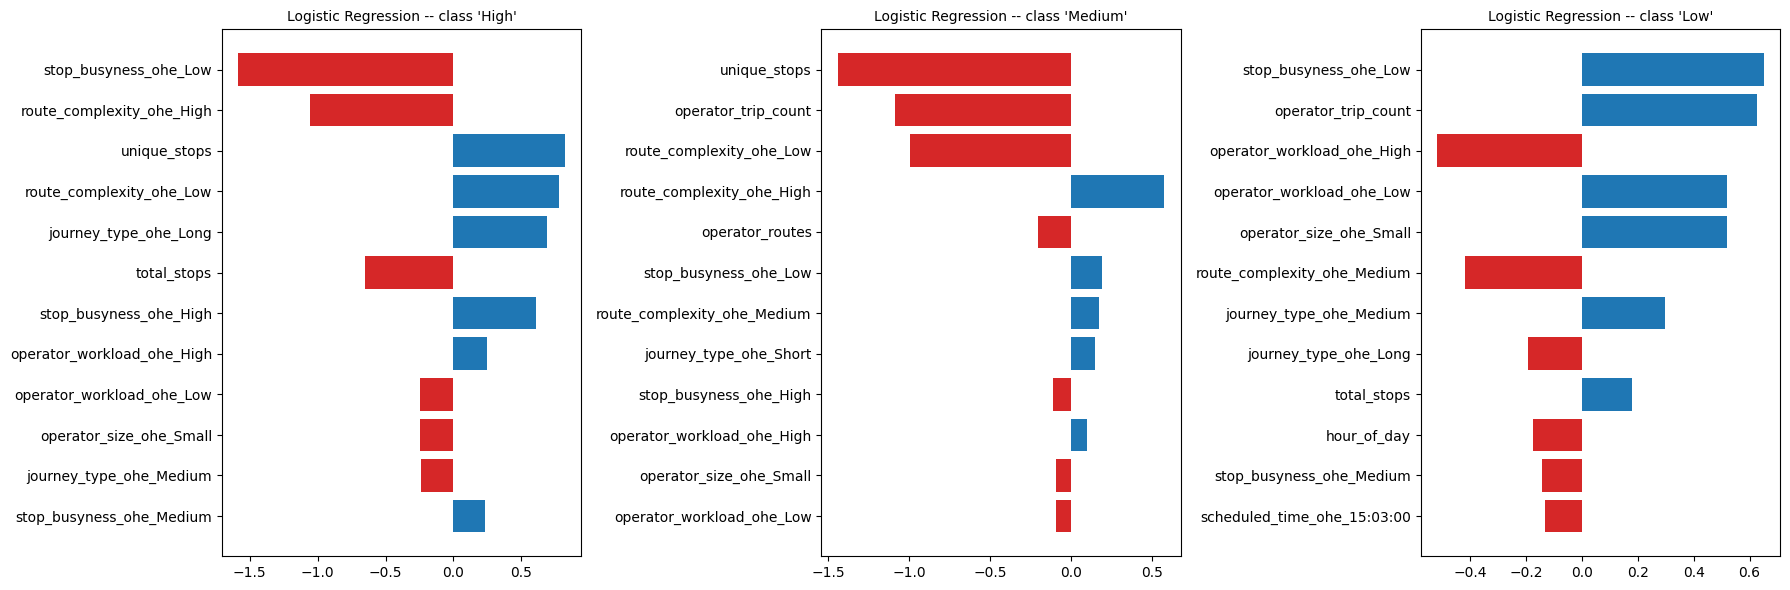

In [15]:
lr_coef = feature_importance["lr_coefficients"]

fig, axes = plt.subplots(1, len(label_names), figsize=(6 * len(label_names), 6))
for ax, class_name in zip(axes, label_names):
    coef_df = pd.DataFrame({"feature": assembler_inputs, "coefficient": lr_coef[class_name]})
    coef_df["abs_coef"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=True).tail(12)
    colors = ["tab:red" if c < 0 else "tab:blue" for c in coef_df["coefficient"]]
    ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
    ax.set_title(f"Logistic Regression -- class '{class_name}'", fontsize=10)
plt.tight_layout()
plt.show()

## Cross-validation results

In [16]:
cv_df = pd.DataFrame(cv_results)
cv_df["params_str"] = cv_df["params"].apply(lambda d: ", ".join(f"{k}={v}" for k, v in d.items()))

for name in model_names:
    sub = cv_df[cv_df["model"] == name].sort_values("avg_f1", ascending=False)
    print(f"\n--- {name} ---")
    print(sub[["params_str", "avg_f1"]].to_string(index=False))


--- Random Forest ---
               params_str   avg_f1
numTrees=100, maxDepth=15 0.496429
numTrees=200, maxDepth=15 0.493012
numTrees=200, maxDepth=20 0.491461
numTrees=100, maxDepth=10 0.490194
numTrees=100, maxDepth=20 0.488789
numTrees=200, maxDepth=10 0.486036

--- Decision Tree ---
                                          params_str   avg_f1
    maxDepth=8, impurity=gini, minInstancesPerNode=5 0.458924
    maxDepth=8, impurity=gini, minInstancesPerNode=1 0.458803
   maxDepth=12, impurity=gini, minInstancesPerNode=5 0.397153
   maxDepth=12, impurity=gini, minInstancesPerNode=1 0.396711
 maxDepth=8, impurity=entropy, minInstancesPerNode=1 0.394563
 maxDepth=8, impurity=entropy, minInstancesPerNode=5 0.394536
   maxDepth=18, impurity=gini, minInstancesPerNode=1 0.369528
   maxDepth=18, impurity=gini, minInstancesPerNode=5 0.364810
maxDepth=12, impurity=entropy, minInstancesPerNode=5 0.345337
maxDepth=12, impurity=entropy, minInstancesPerNode=1 0.345289
maxDepth=18, impurity=entro

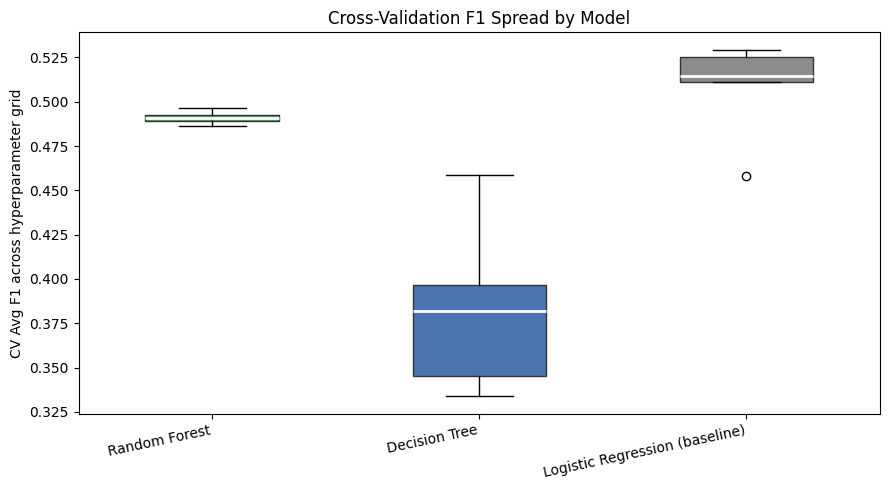

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
data = [cv_df[cv_df["model"] == name]["avg_f1"].values for name in model_names]
box = ax.boxplot(data, tick_labels=model_names, patch_artist=True, widths=0.5,
                  medianprops={"color": "white", "linewidth": 2})
for patch, name in zip(box["boxes"], model_names):
    patch.set_facecolor(model_color(name))
    patch.set_edgecolor("#333333")
ax.set_ylabel("CV Avg F1 across hyperparameter grid")
ax.set_title("Cross-Validation F1 Spread by Model")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

## Training time and scalability

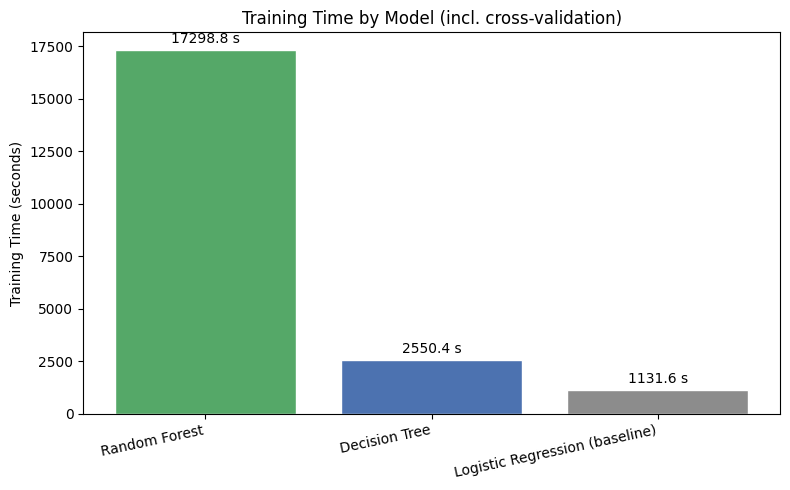

Random Forest takes longer to train but may achieve better F1.


In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [model_color(m) for m in comparison_df["Model"]]
bars = ax.bar(comparison_df["Model"], comparison_df["Training Time (s)"], color=colors, edgecolor="white", linewidth=1)
ax.bar_label(bars, fmt="%.1f s", padding=3, fontsize=10)
ax.set_ylabel("Training Time (seconds)")
ax.set_title("Training Time by Model (incl. cross-validation)")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

print(
    "Random Forest takes longer to train but may achieve better F1."
)

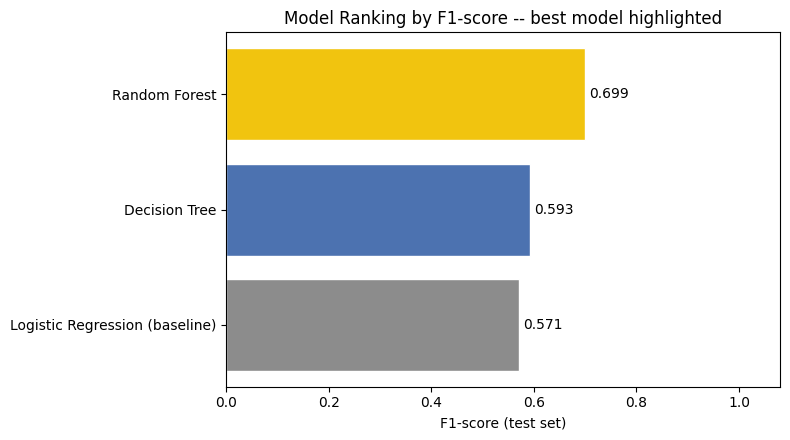

In [19]:
ranked = comparison_df.sort_values("f1", ascending=True)
colors = ["#F1C40F" if m == ranked.iloc[-1]["Model"] else model_color(m) for m in ranked["Model"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(ranked["Model"], ranked["f1"], color=colors, edgecolor="white", linewidth=1)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_xlim(0, 1.08)
ax.set_xlabel("F1-score (test set)")
ax.set_title("Model Ranking by F1-score -- best model highlighted")
plt.tight_layout()
plt.show()

## Final comparison table and recommendation

In [20]:
final_table = comparison_df.sort_values("f1", ascending=False).reset_index(drop=True)
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(final_table.to_string(index=False))

best_name = final_table.iloc[0]["Model"]
baseline_f1 = final_table[final_table["Model"] == "Logistic Regression (baseline)"]["f1"].iloc[0]
best_f1 = final_table.iloc[0]["f1"]

print(f"\nBest model      : {best_name}")
print(f"Baseline (LR) F1: {baseline_f1:.4f}")
print(f"Best model F1   : {best_f1:.4f}")
print(f"Uplift          : {best_f1 - baseline_f1:+.4f}")

FINAL MODEL COMPARISON
                         Model  Training Time (s)  accuracy  weightedPrecision  weightedRecall     f1
                 Random Forest            17298.8    0.6998             0.7007          0.6998 0.6991
                 Decision Tree             2550.4    0.6056             0.6002          0.6056 0.5932
Logistic Regression (baseline)             1131.6    0.5665             0.5773          0.5665 0.5707

Best model      : Random Forest
Baseline (LR) F1: 0.5707
Best model F1   : 0.6991
Uplift          : +0.1284


In [ ]:
spark.stop()
print("Spark session stopped. Notebook 06 complete.")